In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_DE = df[df["job_title_short"]=="Data Engineer"].copy()

In [13]:
df_DE_expl = df_DE.explode(column="job_skills")

In [16]:
df_DE_skillset = df_DE_expl.groupby("job_skills").agg(
    skill_count=("job_skills","count"),
    median_salary=("salary_year_avg","median")
)

In [19]:
df_DE_skillset = df_DE_skillset.sort_values(by="skill_count",ascending=False).head(10)

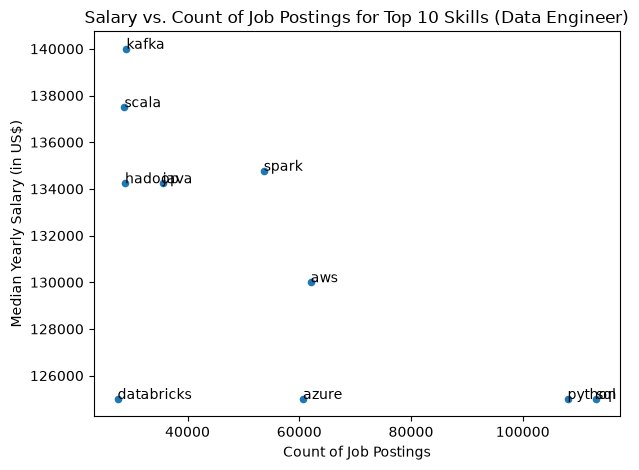

In [30]:
df_DE_skillset.plot(kind="scatter",x="skill_count",y="median_salary")

plt.xlabel("Count of Job Postings")
plt.ylabel("Median Yearly Salary (in US$)")
plt.title("Salary vs. Count of Job Postings for Top 10 Skills (Data Engineer)")

for i,name in enumerate(df_DE_skillset.index):
    plt.text(df_DE_skillset["skill_count"].iloc[i],df_DE_skillset["median_salary"].iloc[i],name)

plt.tight_layout()
plt.show()